# TP 7 : Dask Dataframe et Machine learning distribué

## Exercice 1 Persistance des données

Le répertoire `data/` contient une série de fichiers Parquet. Chaque fichier contient des informations sur des maisons avec les colonnes suivantes : `surface`, `chambres`, `distance_centre`, `anciennete`, et `prix`.

Le code suivant charge un fichier Parquet et retourne la moyenne, l'écart type et le maximum du prix.

In [1]:
import pandas as pd

In [30]:
# chargement du fichier parquet
file_path = 'data/houses_10000000.parquet'

In [9]:
# Charger le fichier Parquet avec Pandas
df = pd.read_parquet(file_path)

# Calculer la moyenne, l'écart type et le maximum du prix
mean_price = df['prix'].mean()
std_price = df['prix'].std()
max_price = df['prix'].max()

# Afficher les résultats
print(f"Moyenne du prix : {mean_price}")
print(f"Écart type du prix : {std_price}")
print(f"Prix maximum : {max_price}")

Moyenne du prix : 433432.55843722494
Écart type du prix : 234576.74775058046
Prix maximum : 891056.2089515486


### Question 1 : Parallélisation avec Dask

1. Réaliser un Traitement Équivalent avec Dask DataFrame

In [10]:
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
# cluster = LocalCluster()
# client = Client() # run on localhost

In [32]:
# Charger le fichier Parquet avec Dask
df_dd = dd.read_parquet(file_path, header=None)

In [ ]:
df_dd

 # repartitioner ou chunksize

,surface,chambres,distance_centre,anciennete,prix
npartitions=1,,,,,
,int64,int64,float64,int64,float64
,...,...,...,...,...


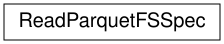

In [6]:
df_dd.visualize()

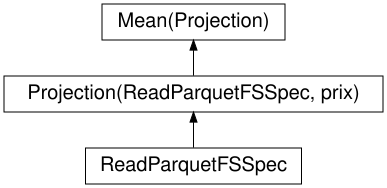

In [36]:
df_dd['prix'].mean().visualize()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Une seule partition, le nombre de partitions est défini par Dask. Il est possible de forcer une taille de chunk ou d'effectuer un repartitionnement, mais cela peut ne pas être intéressant car cela augmente le temps d'exécution.
  </p>
</div>

In [ ]:
# Calculer la moyenne, l'écart type et le maximum du prix
mean_price = df_dd['prix'].mean().compute()
std_price = df_dd['prix'].std().compute()
max_price = df_dd['prix'].max().compute()

# Afficher les résultats
print(f"Moyenne du prix : {mean_price}")
print(f"Écart type du prix : {std_price}")
print(f"Prix maximum : {max_price}")

2. Comparer les temps de restitution des versions pandas et Dask pour des volumétries de données croissantes.

In [14]:
import time
import os
import matplotlib.pyplot as plt

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [26]:
             
datasets_df = []
datasets_dd = []
N_values = []
times_df = []
times_dd = []

listing = os.listdir("data/")
for infile in listing:
    print("\n",infile)
    path = os.path.join("data/", infile)
    
    parts = infile.split("_")
    parts2 = parts[-1].split(".")
    N = int(parts2[0])  
    
    N_values.append(N)

    tic = time.time()
    # Charger le fichier Parquet avec Pandas
    df = pd.read_parquet(path)
    tic = time.time()
    # Calculer la moyenne, l'écart type et le maximum du prix
    mean_price = df['prix'].mean()
    std_price = df['prix'].std()
    max_price = df['prix'].max()
    toc = time.time()
    
    times_df.append(toc - tic)

    tic = time.time()
    # Charger le fichier Parquet avec Dask
    df_dd = dd.read_parquet(path, header=None)
    tic = time.time()
    # Calculer la moyenne, l'écart type et le maximum du prix
    mean_price = df_dd['prix'].mean().compute()
    std_price = df_dd['prix'].std().compute()
    max_price = df_dd['prix'].max().compute()
    toc = time.time()
    times_dd.append(toc - tic)

    # Afficher les résultats
    print(f"Moyenne du prix : {mean_price}")
    print(f"Écart type du prix : {std_price}")
    print(f"Prix maximum : {max_price}")




 houses_10000.parquet
Moyenne du prix : 430642.8722883248
Écart type du prix : 233521.16121838894
Prix maximum : 883716.927189016

 houses_500000.parquet
Moyenne du prix : 432926.85517698183
Écart type du prix : 234926.1272435667
Prix maximum : 895962.8566820562

 houses_100000.parquet
Moyenne du prix : 433432.55843722494
Écart type du prix : 234576.74775058046
Prix maximum : 891056.2089515486

 houses_20000.parquet
Moyenne du prix : 430219.0680159052
Écart type du prix : 234404.22972093424
Prix maximum : 888087.9037145013

 houses_50000.parquet
Moyenne du prix : 433015.1868818822
Écart type du prix : 234526.35279049765
Prix maximum : 892150.4679670474

 houses_1000000.parquet
Moyenne du prix : 432724.5155718959
Écart type du prix : 234947.20876450755
Prix maximum : 901254.0443878206

 houses_10000000.parquet
Moyenne du prix : 433042.5917865228
Écart type du prix : 234959.14361242
Prix maximum : 902805.8571764674


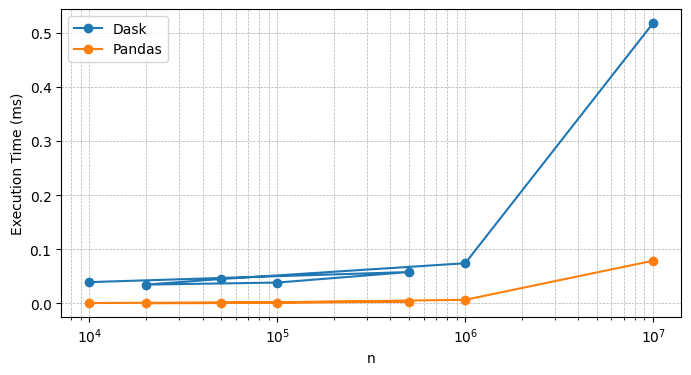

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(N_values, times_dd, marker='o', label=f'Dask')
plt.plot(N_values, times_df, marker='o', label=f'Pandas')
plt.xlabel('n')
plt.xscale('log')
plt.ylabel('Execution Time (ms)')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Dask avait un temps d'exécution plus long, ce qui peut être lié au fait que tous les dd n'ont qu'une seule partition. Dask augmente la complexité du processus, mais n'apporte pas les avantages du parallélisme en n'ayant qu'une seule partition.
  </p>
</div>

## Question 2 : Optimisation avec `persist()`

1. Utiliser la méthode `persist()` pour éviter les chargements de données redondants

In [28]:
times_persist = []

listing = os.listdir("data/")
for infile in listing:
    print("\n", infile)
    path = os.path.join("data/", infile)

    # Using Dask (df_dd)
    tic = time.time()
    # Charger le fichier Parquet avec Dask
    df_dd = dd.read_parquet(path, header=None)

    # Persist the DataFrame in memory to avoid redundant loading
    df_dd_persisted_prix = df_dd['prix'].persist()
    tic = time.time()
    # Calculer la moyenne, l'écart type et le maximum du prix
    mean_price_dd = df_dd_persisted_prix.mean().compute()
    std_price_dd = df_dd_persisted_prix.std().compute()
    max_price_dd = df_dd_persisted_prix.max().compute()
    toc = time.time()
    times_persist.append(toc - tic)
    
    # Afficher les résultats
    print(f"Moyenne du prix : {mean_price_dd}")
    print(f"Écart type du prix : {std_price_dd}")
    print(f"Prix maximum : {max_price_dd}")
    



 houses_10000.parquet
Moyenne du prix : 430642.8722883248
Écart type du prix : 233521.16121838894
Prix maximum : 883716.927189016

 houses_500000.parquet
Moyenne du prix : 432926.85517698183
Écart type du prix : 234926.1272435667
Prix maximum : 895962.8566820562

 houses_100000.parquet
Moyenne du prix : 433432.55843722494
Écart type du prix : 234576.74775058046
Prix maximum : 891056.2089515486

 houses_20000.parquet
Moyenne du prix : 430219.0680159052
Écart type du prix : 234404.22972093424
Prix maximum : 888087.9037145013

 houses_50000.parquet
Moyenne du prix : 433015.1868818822
Écart type du prix : 234526.35279049765
Prix maximum : 892150.4679670474

 houses_1000000.parquet
Moyenne du prix : 432724.5155718959
Écart type du prix : 234947.20876450755
Prix maximum : 901254.0443878206

 houses_10000000.parquet
Moyenne du prix : 433042.5917865228
Écart type du prix : 234959.14361242
Prix maximum : 902805.8571764674


2. Comparer les temps de restitution entre la version Dask optimisée avec `persist()` et les versions précédentes.

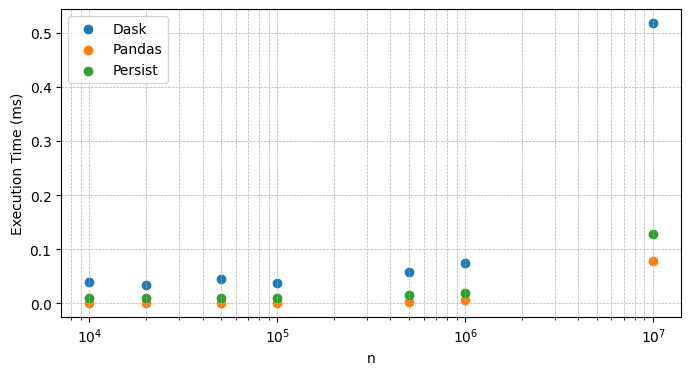

In [29]:
plt.figure(figsize=(8, 4))
plt.scatter(N_values, times_dd, marker='o', label=f'Dask')
plt.scatter(N_values, times_df, marker='o', label=f'Pandas')
plt.scatter(N_values, times_persist, marker='o', label=f'Persist')
plt.xlabel('n')
plt.xscale('log')
plt.ylabel('Execution Time (ms)')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Nous voyons que la fonction persist() a rendu Dask presque aussi efficace que Pandas. persist() transfère les données du disque vers la mémoire, ce qui améliore les performances des calculs ultérieurs sur les mêmes données. Cela permet d'éviter de relire le fichier Parquet pour chaque calcul, accélérant ainsi le flux de travail lors de l'exécution de plusieurs calculs.
  </p>
</div>